In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
(x_train, y_train), (x_test, y_test) = cifar100.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

def build_model():
    model = Sequential([
        Input(shape=(32,32,3)),
        Conv2D(32,(3,3),activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(64,(3,3),activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(256,activation='relu'),
        Dense(100,activation='softmax')
    ])
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

169001437/169001437 [==============================] - 552s 3us/step


In [3]:
model1 = build_model()
history1 = model1.fit(x_train, y_train, epochs=5, validation_data=(x_test,y_test))

Epoch 1/5
1563/1563 [==============================] - 60s 38ms/step - loss: 3.5934 - accuracy: 0.1594 - val_loss: 3.0197 - val_accuracy: 0.2662
Epoch 2/5
1563/1563 [==============================] - 62s 40ms/step - loss: 2.7957 - accuracy: 0.3089 - val_loss: 2.6928 - val_accuracy: 0.3299
Epoch 3/5
1563/1563 [==============================] - 63s 40ms/step - loss: 2.4563 - accuracy: 0.3754 - val_loss: 2.6296 - val_accuracy: 0.3471
Epoch 4/5
1563/1563 [==============================] - 66s 42ms/step - loss: 2.2333 - accuracy: 0.4210 - val_loss: 2.5240 - val_accuracy: 0.3708
Epoch 5/5
1563/1563 [==============================] - 66s 42ms/step - loss: 2.0369 - accuracy: 0.4656 - val_loss: 2.4996 - val_accuracy: 0.3803


In [4]:
datagen = ImageDataGenerator(rotation_range=15, horizontal_flip=True)
datagen.fit(x_train)

model2 = build_model()
history2 = model2.fit(datagen.flow(x_train,y_train,batch_size=64),
                      epochs=5, validation_data=(x_test,y_test))

Epoch 1/5
782/782 [==============================] - 68s 85ms/step - loss: 3.7087 - accuracy: 0.0089 - val_loss: 3.2551 - val_accuracy: 0.0112
Epoch 2/5
782/782 [==============================] - 70s 89ms/step - loss: 3.0475 - accuracy: 0.0108 - val_loss: 2.8955 - val_accuracy: 0.0059
Epoch 3/5
782/782 [==============================] - 73s 93ms/step - loss: 2.7877 - accuracy: 0.0117 - val_loss: 2.7677 - val_accuracy: 0.0091
Epoch 4/5
782/782 [==============================] - 58s 74ms/step - loss: 2.6290 - accuracy: 0.0107 - val_loss: 2.6265 - val_accuracy: 0.0128
Epoch 5/5
782/782 [==============================] - 54s 69ms/step - loss: 2.5066 - accuracy: 0.0112 - val_loss: 2.6069 - val_accuracy: 0.0064


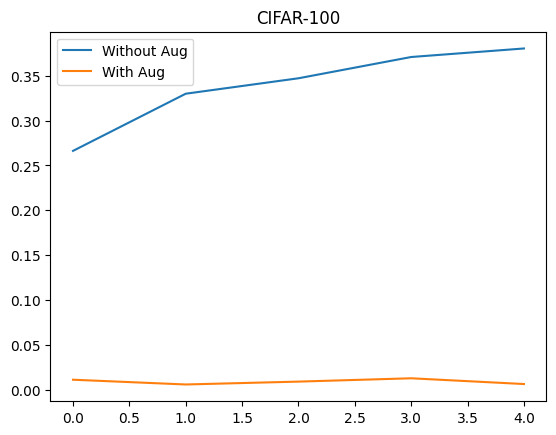

Conclusion: No Change ❌


In [5]:
plt.plot(history1.history['val_accuracy'], label='Without Aug')
plt.plot(history2.history['val_accuracy'], label='With Aug')
plt.legend(); plt.title("CIFAR-100"); plt.show()

print("Conclusion:", "Improved ✅" if max(history2.history['val_accuracy']) > max(history1.history['val_accuracy']) else "No Change ❌")